# SingleLayerMultilayerPerceptronNetwork
This notebook contains two implementations: a Single-Layer Perceptron (Linear Combiner) and a Multilayer Feed-Forward Network. Both include original input data, initial weights and biases, explicit activation functions, step-by-step weight updates over at least three iterations/epochs, and architecture visualization.

Default behavior: uses `last_login_digit = 3` (odd) to run the Multilayer demo. Change `last_login_digit` in the runner cell to choose which demo to execute.

In [1]:
# Cell: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from copy import deepcopy
%matplotlib inline

## Activation functions
We define `signum` (threshold) and `sigmoid` + derivative (for backprop) here.

In [2]:
def signum(x, threshold=0.0):
    """Signum/threshold activation. Returns 1 if x>threshold else -1."""
    return np.where(x > threshold, 1, -1)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_derivative(s):
    # s is sigmoid(x)
    return s * (1.0 - s)

## Single-Layer Perceptron (Linear Combiner) implementation
Class, training loop, and demonstration using original data and weights. Uses perceptron learning rule and `signum` activation.

In [3]:
class SingleLayerPerceptron:
    def __init__(self, number_of_inputs, initial_weights=None, initial_bias=0.0, learning_rate=1.0, activation_fn=signum, threshold=0.0):
        self.number_of_inputs = number_of_inputs
        if initial_weights is None:
            self.weights = np.zeros(number_of_inputs, dtype=float)
        else:
            self.weights = np.array(initial_weights, dtype=float)
        self.bias = float(initial_bias)
        self.learning_rate = float(learning_rate)
        self.activation_fn = activation_fn
        self.threshold = threshold
        self.weight_history = []

    def forward(self, input_vector):
        net_input = np.dot(self.weights, input_vector) + self.bias
        output = self.activation_fn(net_input, threshold=self.threshold)
        return output, net_input

    def train_one_epoch(self, input_vectors, target_values):
        # Perceptron learning rule: w <- w + lr * (target - output) * x
        for input_vector, target_value in zip(input_vectors, target_values):
            output, net_input = self.forward(input_vector)
            error = target_value - output
            # update weights and bias
            self.weights = self.weights + self.learning_rate * error * np.array(input_vector, dtype=float)
            self.bias = self.bias + self.learning_rate * error
        # record after processing all patterns once
        self.weight_history.append((deepcopy(self.weights), float(self.bias)))

    def fit(self, input_vectors, target_values, epochs=3):
        # initialize history with initial weights
        self.weight_history = []
        self.weight_history.append((deepcopy(self.weights), float(self.bias)))
        for epoch in range(epochs):
            self.train_one_epoch(input_vectors, target_values)

    def get_weight_history_dataframe(self):
        rows = []
        for idx, (w, b) in enumerate(self.weight_history):
            row = {'iteration': idx}
            for i, wi in enumerate(w):
                row[f'weight_{i}'] = wi
            row['bias'] = b
            rows.append(row)
        return pd.DataFrame(rows)

### Single-layer demonstration with original data
We define original input vectors, initial synaptic weights, and bias. Then run 3 iterations and present the weight table.

In [6]:
# Define original inputs, initial weights, and bias for Single-Layer Perceptron demo
input_vectors_single_layer = [
    [1, 1],  # pattern A
    [1, -1], # pattern B
    [-1, 1], # pattern C
    [-1, -1] # pattern D
]
# Targets (choose a simple linearly separable mapping)
target_values_single_layer = [1, 1, -1, -1]
# Initial weights and bias (original values specified by us)
initial_weights_single_layer = [0.2, -0.1]
initial_bias_single_layer = 0.0
learning_rate_single_layer = 0.5

# Instantiate and train
single_layer_model = SingleLayerPerceptron(number_of_inputs=2, initial_weights=initial_weights_single_layer, initial_bias=initial_bias_single_layer, learning_rate=learning_rate_single_layer, activation_fn=signum, threshold=0.0)
single_layer_model.fit(input_vectors_single_layer, target_values_single_layer, epochs=3)

# Show weight update table (at least three iterations)
weight_history_df_single = single_layer_model.get_weight_history_dataframe()
weight_history_df_single

,iteration,weight_0,weight_1,bias
0,0,0.2,-0.1,0.0
1,1,0.2,-0.1,0.0
2,2,0.2,-0.1,0.0
3,3,0.2,-0.1,0.0


Show a calculation of the output for one input using the final weights.

In [7]:
# pick a sample input and compute output using final weights
sample_input = np.array([1, 1])
final_weights, final_bias = single_layer_model.weight_history[-1]
net_input_sample = np.dot(final_weights, sample_input) + final_bias
output_sample = signum(net_input_sample)
print('Sample input:', sample_input)
print('Net input:', net_input_sample)
print('Output (signum):', output_sample)

Sample input: [1 1]
Net input: 0.1
Output (signum): 1


## Multilayer Feed-Forward Network implementation
A small multilayer network with one hidden layer. Uses `sigmoid` activation and gradient descent backpropagation. Weight history is recorded per epoch.

In [8]:
class MultilayerFeedForwardNetwork:
    def __init__(self, input_size, hidden_layer_size, output_size, initial_weights_hidden=None, initial_weights_output=None, initial_bias_hidden=None, initial_bias_output=None, learning_rate=0.5):
        self.input_size = input_size
        self.hidden_layer_size = hidden_layer_size
        self.output_size = output_size
        # Initialize weights: hidden weights shape (hidden_layer_size, input_size)
        if initial_weights_hidden is None:
            self.weights_hidden = np.random.randn(hidden_layer_size, input_size) * 0.1
        else:
            self.weights_hidden = np.array(initial_weights_hidden, dtype=float)
        # Output weights shape (output_size, hidden_layer_size)
        if initial_weights_output is None:
            self.weights_output = np.random.randn(output_size, hidden_layer_size) * 0.1
        else:
            self.weights_output = np.array(initial_weights_output, dtype=float)
        # biases
        if initial_bias_hidden is None:
            self.bias_hidden = np.zeros(hidden_layer_size, dtype=float)
        else:
            self.bias_hidden = np.array(initial_bias_hidden, dtype=float)
        if initial_bias_output is None:
            self.bias_output = np.zeros(output_size, dtype=float)
        else:
            self.bias_output = np.array(initial_bias_output, dtype=float)
        self.learning_rate = float(learning_rate)
        self.weight_history = []

    def forward(self, input_vector):
        # input_vector is 1D array length input_size
        hidden_net = np.dot(self.weights_hidden, input_vector) + self.bias_hidden
        hidden_activation = sigmoid(hidden_net)
        output_net = np.dot(self.weights_output, hidden_activation) + self.bias_output
        output_activation = sigmoid(output_net)
        return hidden_activation, output_activation, hidden_net, output_net

    def backward(self, input_vector, hidden_activation, output_activation, target_vector):
        # output layer error
        target_vector = np.array(target_vector, dtype=float)
        output_error = target_vector - output_activation
        output_delta = output_error * sigmoid_derivative(output_activation)
        # hidden layer error
        hidden_error = np.dot(self.weights_output.T, output_delta)
        hidden_delta = hidden_error * sigmoid_derivative(hidden_activation)
        # weight updates (gradient descent)
        # output weights update
        output_weight_updates = self.learning_rate * np.outer(output_delta, hidden_activation)
        # hidden weights update
        hidden_weight_updates = self.learning_rate * np.outer(hidden_delta, input_vector)
        # apply updates
        self.weights_output += output_weight_updates
        self.bias_output += self.learning_rate * output_delta
        self.weights_hidden += hidden_weight_updates
        self.bias_hidden += self.learning_rate * hidden_delta

    def train(self, input_vectors, target_vectors, epochs=3):
        # record initial weights
        self.weight_history = []
        self.weight_history.append((deepcopy(self.weights_hidden), deepcopy(self.bias_hidden), deepcopy(self.weights_output), deepcopy(self.bias_output)))
        for epoch in range(epochs):
            for input_vector, target_vector in zip(input_vectors, target_vectors):
                hidden_act, output_act, _, _ = self.forward(input_vector)
                self.backward(input_vector, hidden_act, output_act, target_vector)
            # record after each epoch
            self.weight_history.append((deepcopy(self.weights_hidden), deepcopy(self.bias_hidden), deepcopy(self.weights_output), deepcopy(self.bias_output)))

    def get_weight_history_dataframes(self):
        # return two DataFrames: hidden weights & output weights over iterations
        hidden_rows = []
        output_rows = []
        for idx, (w_h, b_h, w_o, b_o) in enumerate(self.weight_history):
            row_h = {'iteration': idx}
            for i in range(w_h.shape[0]):
                for j in range(w_h.shape[1]):
                    row_h[f'h_w_{i}_{j}'] = w_h[i, j]
            for i in range(len(b_h)):
                row_h[f'h_bias_{i}'] = b_h[i]
            hidden_rows.append(row_h)
            row_o = {'iteration': idx}
            for i in range(w_o.shape[0]):
                for j in range(w_o.shape[1]):
                    row_o[f'o_w_{i}_{j}'] = w_o[i, j]
            for i in range(len(b_o)):
                row_o[f'o_bias_{i}'] = b_o[i]
            output_rows.append(row_o)
        return pd.DataFrame(hidden_rows), pd.DataFrame(output_rows)

### Multilayer demonstration with original data
Define a small dataset, initial weights, and train for at least three epochs. Show weight update tables and a sample output calculation.

In [9]:
# Define original dataset for multilayer demo (unique inputs/outputs)
input_vectors_multilayer = [
    np.array([0.0, 0.0]),
    np.array([0.0, 1.0]),
    np.array([1.0, 0.0]),
    np.array([1.0, 1.0])
]
# We'll try to learn XOR-ish mapping (not linearly separable) to justify hidden layer
target_vectors_multilayer = [
    np.array([0.0]),
    np.array([1.0]),
    np.array([1.0]),
    np.array([0.0])
]
# initial weights chosen explicitly for reproducibility
initial_weights_hidden_multilayer = [[0.2, -0.3], [0.4, 0.1]]  # 2 hidden neurons, 2 inputs
initial_bias_hidden_multilayer = [0.0, 0.0]
initial_weights_output_multilayer = [[0.1, -0.2]]  # 1 output neuron, 2 hidden neurons
initial_bias_output_multilayer = [0.0]

multilayer_model = MultilayerFeedForwardNetwork(input_size=2, hidden_layer_size=2, output_size=1, initial_weights_hidden=initial_weights_hidden_multilayer, initial_weights_output=initial_weights_output_multilayer, initial_bias_hidden=initial_bias_hidden_multilayer, initial_bias_output=initial_bias_output_multilayer, learning_rate=0.5)

# Train for 3 epochs and record weight history
multilayer_model.train(input_vectors_multilayer, target_vectors_multilayer, epochs=3)
hidden_weights_history_df, output_weights_history_df = multilayer_model.get_weight_history_dataframes()
hidden_weights_history_df

,iteration,h_w_0_0,h_w_0_1,h_w_1_0,h_w_1_1,h_bias_0,h_bias_1
0,0,0.200000,-0.300000,0.400000,0.100000,0.000000,0.000000
1,1,0.199443,-0.300978,0.399337,0.098509,-0.000943,-0.001460
2,2,0.198873,-0.301964,0.398702,0.097054,-0.001911,-0.002860
3,3,0.198292,-0.302956,0.398089,0.095630,-0.002901,-0.004212


In [10]:
# show output weights table too
output_weights_history_df

,iteration,o_w_0_0,o_w_0_1,o_bias_0
0,0,0.100000,-0.200000,0.000000
1,1,0.103010,-0.196293,0.006581
2,2,0.105466,-0.193222,0.012038
3,3,0.107463,-0.190678,0.016566


In [11]:
# sample forward computation using final weights for input [1,0]
sample_input_ml = np.array([1.0, 0.0])
hidden_activation_sample, output_activation_sample, hidden_net_sample, output_net_sample = multilayer_model.forward(sample_input_ml)
print('Sample input:', sample_input_ml)
print('Hidden net:', hidden_net_sample)
print('Hidden activation (sigmoid):', hidden_activation_sample)
print('Output net:', output_net_sample)
print('Output activation (sigmoid):', output_activation_sample)

Sample input: [1. 0.]
Hidden net: [0.19539157 0.39387719]
Hidden activation (sigmoid): [0.54869308 0.5972157 ]
Output net: [-0.03834603]
Output activation (sigmoid): [0.49041467]


## Architecture visualization
Draw the network architecture (input, hidden, output) using networkx to produce a graph similar to the provided screenshot.

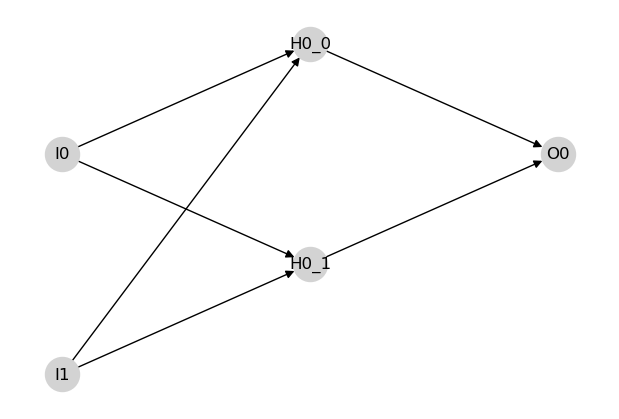

In [12]:
def draw_feedforward_architecture(number_of_inputs, hidden_layer_sizes, number_of_outputs, figsize=(6,6)):
    G = nx.DiGraph()
    positions = {}
    # input layer positions
    for i in range(number_of_inputs):
        node_name = f'I{i}'
        G.add_node(node_name, layer='input')
        positions[node_name] = (0, -i)
    # hidden layers positions
    for h_idx, h_size in enumerate(hidden_layer_sizes):
        for j in range(h_size):
            node_name = f'H{h_idx}_{j}'
            G.add_node(node_name, layer=f'hidden{h_idx}')
            positions[node_name] = (h_idx+1, -j + (h_size-1)/2.0)
    # output layer positions
    for k in range(number_of_outputs):
        node_name = f'O{k}'
        G.add_node(node_name, layer='output')
        positions[node_name] = (len(hidden_layer_sizes)+1, -k)
    # add edges fully connected between successive layers
    # input -> first hidden
    for i in range(number_of_inputs):
        for j in range(hidden_layer_sizes[0]):
            G.add_edge(f'I{i}', f'H0_{j}')
    # hidden layers between themselves if more than one
    for h_idx in range(len(hidden_layer_sizes)-1):
        for i in range(hidden_layer_sizes[h_idx]):
            for j in range(hidden_layer_sizes[h_idx+1]):
                G.add_edge(f'H{h_idx}_{i}', f'H{h_idx+1}_{j}')
    # last hidden -> outputs
    for i in range(hidden_layer_sizes[-1]):
        for k in range(number_of_outputs):
            G.add_edge(f'H{len(hidden_layer_sizes)-1}_{i}', f'O{k}')
    plt.figure(figsize=figsize)
    nx.draw(G, positions, with_labels=True, node_size=600, node_color='lightgray', arrowsize=12)
    plt.axis('off')
    plt.show()

# Draw architecture used in multilayer demo: 2 inputs, one hidden layer of 2 neurons, 1 output
draw_feedforward_architecture(number_of_inputs=2, hidden_layer_sizes=[2], number_of_outputs=1, figsize=(6,4))

## Runner control cell
Choose which demo to run based on the last login digit. Default is `3` (odd) -> run the Multilayer demo. Change `last_login_digit` value to test the other branch.

In [14]:
# Runner: set last_login_digit here (use your last login digit). Default=3 (odd -> multilayer).
last_login_digit = 3

if last_login_digit % 2 == 0:
    print('Last digit is even -> running Single-Layer Perceptron demo (trained earlier).')
    display(weight_history_df_single)
    print('\nSample output calculation using final single-layer weights:')
    print('Input [1,1] ->', signum(np.dot(single_layer_model.weight_history[-1][0], np.array([1,1])) + single_layer_model.weight_history[-1][1]))
else:
    print('Last digit is odd -> running Multilayer Feed-Forward demo (trained earlier).')
    print('
Hidden layer weight history:')
    display(hidden_weights_history_df)
    print('
Output layer weight history:')
    display(output_weights_history_df)
    print('
Sample forward calculation using final multilayer weights for input [1,0]:')
    h_act, o_act, h_net, o_net = multilayer_model.forward(np.array([1.0,0.0]))
    print('Hidden net:', h_net)
    print('Hidden act:', h_act)
    print('Output net:', o_net)
    print('Output act:', o_act)

SyntaxError: unterminated string literal (detected at line 11) (2897482840.py, line 11)